In [11]:
import os
import joblib
import psycopg as pg
import numpy as np
import pandas as pd
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import CatBoostEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, precision_score, recall_score, log_loss

In [33]:
TABLE_NAME = "users_churn" # таблица с данными в postgres 

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "eda_experiment" # напишите название вашего эксперимента
RUN_NAME = "eda"

ASSETS_DIR = "assets"

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

os.makedirs(ASSETS_DIR, exist_ok=True)

pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

sns.set_style("white")
sns.set_theme(style="whitegrid") 

In [37]:
connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

# определим название таблицы, в которой хранятся наши данные.
TABLE_NAME = "users_churn"

# эта конструкция создаёт контекстное управление для соединения с базой данных 
# оператор with гарантирует, что соединение будет корректно закрыто после выполнения всех операций 
# закрыто оно будет даже в случае ошибки, чтобы не допустить "утечку памяти"
with pg.connect(**connection) as conn:

# создаёт объект курсора для выполнения запросов к базе данных
# с помощью метода execute() выполняется SQL-запрос для выборки данных из таблицы TABLE_NAME
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

<Axes: xlabel='type', ylabel='count'>

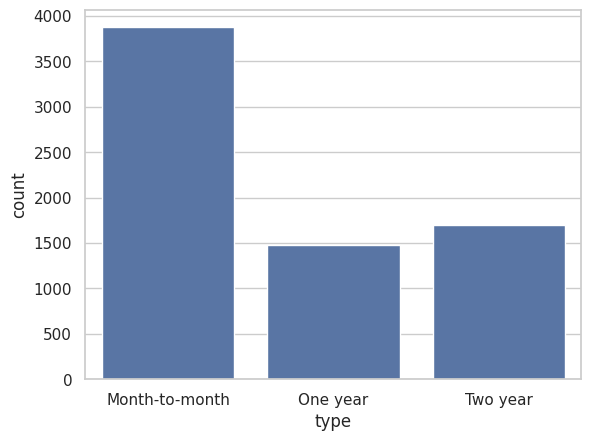

In [38]:
x = "type"
y = "customer_id"
stat = ["count"]
agg_df = df.groupby(x)[y].agg(stat).reset_index()
sns.barplot(data=agg_df, x=x, y=stat[0])

In [39]:
binary_columns = [
    "online_security", 
    "online_backup", 
    "device_protection", 
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "senior_citizen",
    "partner",
    "dependents",
]
df[binary_columns].apply(lambda x: x.value_counts()).T

,No,Yes,0,1
online_security,3498.0,2019.0,NaN,NaN
online_backup,3088.0,2429.0,NaN,NaN
device_protection,3095.0,2422.0,NaN,NaN
tech_support,3473.0,2044.0,NaN,NaN
streaming_tv,2810.0,2707.0,NaN,NaN
streaming_movies,2785.0,2732.0,NaN,NaN
senior_citizen,NaN,NaN,5901.0,1142.0
partner,3641.0,3402.0,NaN,NaN
dependents,4933.0,2110.0,NaN,NaN


In [ ]:
charges_columns = [
    "monthly_charges",
    "total_charges",
]
stats = ["mean", "median", lambda x: x.mode().iloc[0]]
x = "begin_date"

,begin_date,mean,median,<lambda_0>
0,2013-10-01,104.800000,104.150,92.45
1,2013-11-01,108.325000,108.325,108.05
2,2013-12-01,91.066667,93.700,65.30
3,2014-01-01,95.864286,104.050,54.20
4,2014-02-01,80.934153,89.475,24.75
...,...,...,...,...
72,2019-10-01,56.259705,58.500,19.95
73,2019-11-01,54.602110,55.800,20.20
74,2019-12-01,52.312955,54.050,19.90
75,2020-01-01,37.909013,25.400,19.75


In [49]:
df.groupby(x)[charges_columns[0]].agg(stats).reset_index()

,begin_date,mean,median,<lambda_0>
0,2013-10-01,104.800000,104.150,92.45
1,2013-11-01,108.325000,108.325,108.05
2,2013-12-01,91.066667,93.700,65.30
3,2014-01-01,95.864286,104.050,54.20
4,2014-02-01,80.934153,89.475,24.75
...,...,...,...,...
72,2019-10-01,56.259705,58.500,19.95
73,2019-11-01,54.602110,55.800,20.20
74,2019-12-01,52.312955,54.050,19.90
75,2020-01-01,37.909013,25.400,19.75


In [50]:
df.groupby(x)[charges_columns[1]].agg(stats).reset_index()

IndexError: single positional indexer is out-of-bounds

In [ ]:
df